In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Set visual style for the Chief Data Officer
sns.set_theme(style="whitegrid")

In [2]:
np.random.seed(2026)
n = 1000

# 1. Create the base data
data = {
    'Applicant_ID': range(1001, 1001 + n),
    'Province': np.random.choice(['Phnom Penh', 'Siem Reap', 'Battambang', 'PP', 'phnom penh', 'SR'], n),
    'Age': np.random.randint(18, 90, n),
    'Monthly_Income_USD': np.random.normal(550, 300, n).round(2), # Creates negatives
    'Education': np.random.choice(['High School', 'Bachelor', 'Master', None], n, p=[0.4, 0.3, 0.2, 0.1]),
    'Digital_Savings_User': np.random.choice([0, 1], n, p=[0.45, 0.55])
}
df = pd.DataFrame(data)

# 2. Inject intentional errors for cleaning demonstration
df.at[10, 'Monthly_Income_USD'] = 55000.00 # High outlier
df.loc[df.sample(50).index, 'Monthly_Income_USD'] = np.nan # Missing values

# 3. Realistic Loan Approval Logic
def calculate_loan(row):
    income = row['Monthly_Income_USD'] if pd.notnull(row['Monthly_Income_USD']) else 300
    prob = (income / 2500) + (0.20 if row['Digital_Savings_User'] == 1 else 0)
    return 1 if np.random.random() < np.clip(prob, 0.05, 0.95) else 0

df['Loan_Approved'] = df.apply(calculate_loan, axis=1)
print("✅ Cell 1: Raw Dataset Ready.")

✅ Cell 1: Raw Dataset Ready.


In [3]:
df.head()

,Applicant_ID,Province,Age,Monthly_Income_USD,Education,Digital_Savings_User,Loan_Approved
0,1001,Siem Reap,71,520.99,Bachelor,1,1
1,1002,Battambang,73,560.92,None,1,0
2,1003,Phnom Penh,63,787.70,High School,0,0
3,1004,SR,41,620.94,Master,1,0
4,1005,SR,66,77.60,Bachelor,0,0


In [4]:
df.shape

(1000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Applicant_ID          1000 non-null   int64  
 1   Province              1000 non-null   object 
 2   Age                   1000 non-null   int64  
 3   Monthly_Income_USD    950 non-null    float64
 4   Education             891 non-null    object 
 5   Digital_Savings_User  1000 non-null   int64  
 6   Loan_Approved         1000 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 54.8+ KB


In [6]:
df.isnull().sum()

Applicant_ID              0
Province                  0
Age                       0
Monthly_Income_USD       50
Education               109
Digital_Savings_User      0
Loan_Approved             0
dtype: int64

In [7]:
df.describe()

,Applicant_ID,Age,Monthly_Income_USD,Digital_Savings_User,Loan_Approved
count,1000.000000,1000.00000,950.000000,1000.000000,1000.000000
mean,1500.500000,51.53200,612.676811,0.547000,0.342000
std,288.819436,20.45907,1792.821751,0.498035,0.474617
min,1001.000000,18.00000,-306.120000,0.000000,0.000000
25%,1250.750000,33.00000,343.712500,0.000000,0.000000
50%,1500.500000,52.00000,554.150000,1.000000,0.000000
75%,1750.250000,69.00000,769.827500,1.000000,1.000000
max,2000.000000,89.00000,55000.000000,1.000000,1.000000


Negative Incomes found: 38
Missing Values: 
Applicant_ID              0
Province                  0
Age                       0
Monthly_Income_USD       50
Education               109
Digital_Savings_User      0
Loan_Approved             0
dtype: int64


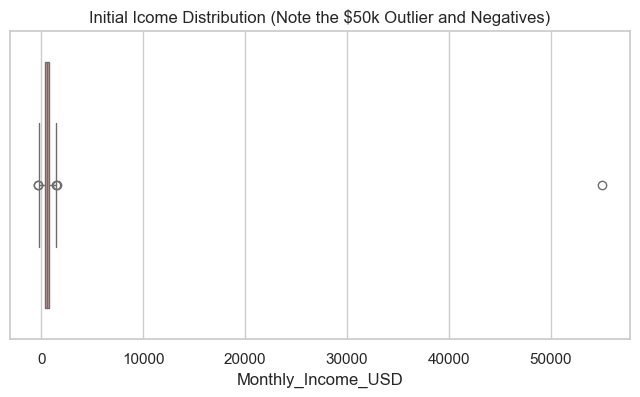

In [9]:
print(f'Negative Incomes found: {(df['Monthly_Income_USD']<0).sum()}')
print(f'Missing Values: \n{df.isnull().sum()}')

plt.figure(figsize = (8,4))
sns.boxplot(x='Monthly_Income_USD', color = 'salmon', data=df)
plt.title('Initial Icome Distribution (Note the $50k Outlier and Negatives)')
plt.show()

In [10]:
df.Province.unique()

array(['Siem Reap', 'Battambang', 'Phnom Penh', 'SR', 'phnom penh', 'PP'],
      dtype=object)

In [11]:
df['Province'] = df['Province'].str.strip().str.title()
mapping = {'Sr' : 'Siem Reap', 'Pp': 'Phnom Penh'}
df['Province'] = df['Province'].replace(mapping)
print(df['Province'].unique())

['Siem Reap' 'Battambang' 'Phnom Penh']


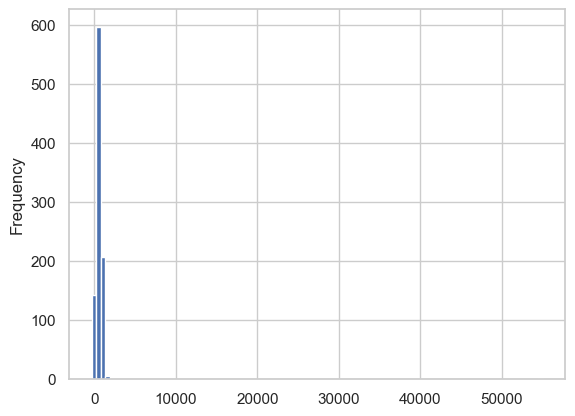

In [12]:
df['Monthly_Income_USD'].plot.hist(bins = 100);

In [14]:
df['Monthly_Income_USD'] = df['Monthly_Income_USD'].clip(lower = 0)

In [16]:
(df['Monthly_Income_USD'] < 0).sum()

np.int64(0)

In [17]:
#Identify outliers in Income using IQR
Q1 = df['Monthly_Income_USD'].quantile(0.25)
Q3 = df['Monthly_Income_USD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Monthly_Income_USD'] = np.where(df['Monthly_Income_USD']> upper_bound, upper_bound, df['Monthly_Income_USD'])

In [18]:
df.groupby('Province')['Monthly_Income_USD'].mean()

Province
Battambang    563.010952
Phnom Penh    554.704725
Siem Reap     567.859154
Name: Monthly_Income_USD, dtype: float64

In [19]:
df['Monthly_Income_USD'] = df.groupby('Province')['Monthly_Income_USD'].transform(lambda x : x.fillna(x.median()))
df['Education'] = df['Education'].fillna('Unknown')

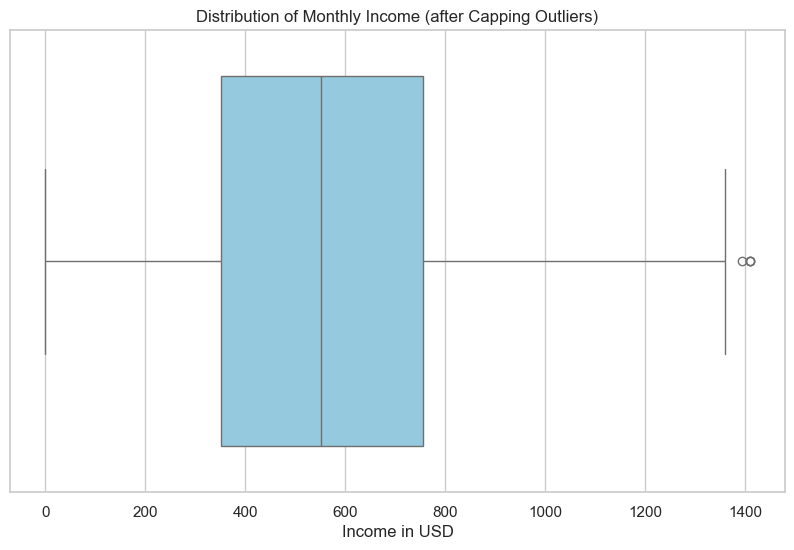

In [20]:
plt.figure(figsize = (10,6))
sns.boxplot(x = 'Monthly_Income_USD', data=df, color = 'skyblue')
plt.title('Distribution of Monthly Income (after Capping Outliers)')
plt.xlabel('Income in USD')
plt.show()

In [22]:
df.isnull().sum()

Applicant_ID            0
Province                0
Age                     0
Monthly_Income_USD      0
Education               0
Digital_Savings_User    0
Loan_Approved           0
Digital_Age_Score       0
dtype: int64

In [21]:
# Create a new feature : Digital Engagement Score
# (Combining age and digital usage to see if younger users are more 'digital-ready')
df['Digital_Age_Score'] = df['Digital_Savings_User']/df['Age']

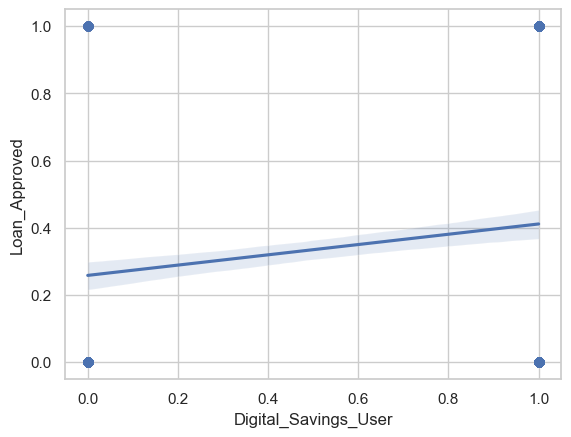

In [23]:
sns.regplot(x = 'Digital_Savings_User', y = 'Loan_Approved', data = df)
plt.show()

In [24]:
# Normalization (0 to 1) for Income
scaler_mm = MinMaxScaler()
df['Income_Normalized'] = scaler_mm.fit_transform(df[['Monthly_Income_USD']])

# Standardization (Mean 0 and Std 1) for Age
scaler_std = StandardScaler()
df['Age_Standardized'] = scaler_std.fit_transform(df[['Age']])

print(df[['Monthly_Income_USD', 'Income_Normalized', 'Age', 'Age_Standardized']].head())

   Monthly_Income_USD  Income_Normalized  Age  Age_Standardized
0              520.99           0.369759   71          0.952035
1              560.92           0.398098   73          1.049840
2              787.70           0.559049   63          0.560814
3              620.94           0.440696   41         -0.515041
4               77.60           0.055075   66          0.707522


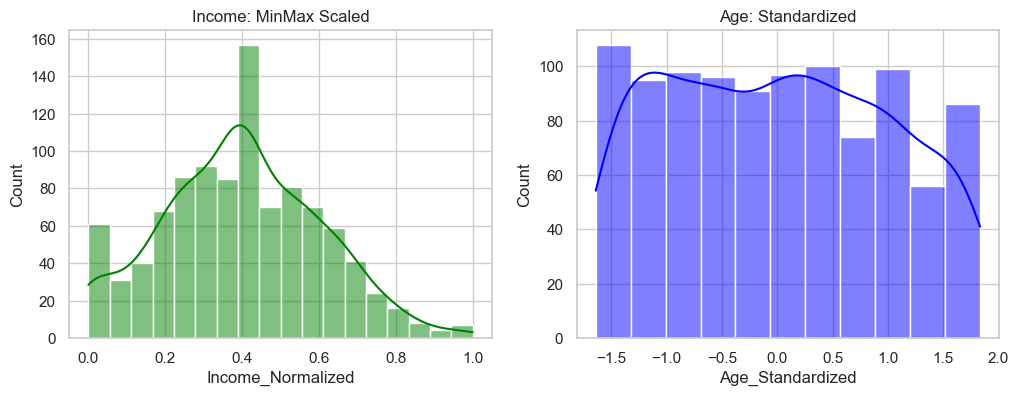

In [65]:
fig, ax = plt.subplots(1,2, figsize = (12,4))
sns.histplot(df['Income_Normalized'], kde= True, ax=ax[0], color = 'green').set_title('Income: MinMax Scaled')
sns.histplot(df['Age_Standardized'], kde= True, ax=ax[1], color = 'blue').set_title('Age: Standardized')
plt.show()

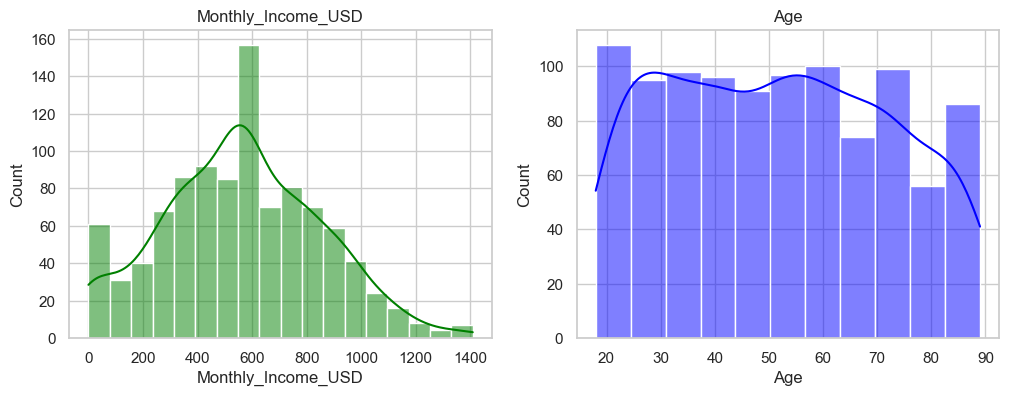

In [68]:
fig, ax = plt.subplots(1,2, figsize = (12,4))
sns.histplot(df['Monthly_Income_USD'], kde = True, ax = ax[0], color = 'green').set_title('Monthly_Income_USD')
sns.histplot(df['Age'], kde = True, ax=ax[1], color = 'blue').set_title('Age')
plt.show()

In [25]:
df['Digital_Savings_User'].corr(df['Loan_Approved'])

np.float64(0.1606084077944287)

In [26]:
df.head()

,Applicant_ID,Province,Age,Monthly_Income_USD,Education,Digital_Savings_User,Loan_Approved,Digital_Age_Score,Income_Normalized,Age_Standardized
0,1001,Siem Reap,71,520.99,Bachelor,1,1,0.014085,0.369759,0.952035
1,1002,Battambang,73,560.92,Unknown,1,0,0.013699,0.398098,1.049840
2,1003,Phnom Penh,63,787.70,High School,0,0,0.000000,0.559049,0.560814
3,1004,Siem Reap,41,620.94,Master,1,0,0.024390,0.440696,-0.515041
4,1005,Siem Reap,66,77.60,Bachelor,0,0,0.000000,0.055075,0.707522


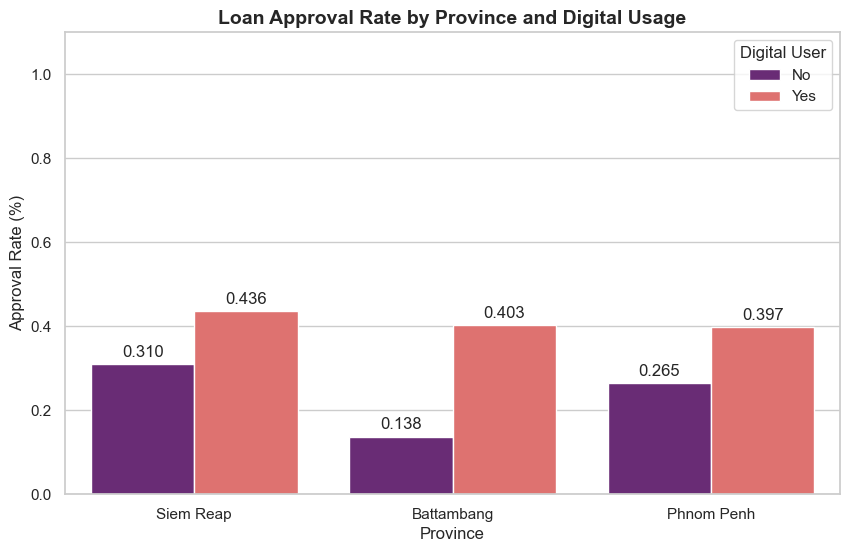

In [69]:
plt.figure(figsize = (10,6))
ax = sns.barplot(data=df, x='Province', y='Loan_Approved', hue='Digital_Savings_User', palette = 'magma', errorbar = None)
plt.title('Loan Approval Rate by Province and Digital Usage', fontsize = 14, fontweight = 'bold')
h ,l = ax.get_legend_handles_labels()
ax.legend(h, ['No', 'Yes'], title = 'Digital User')
for container in ax.containers:
    ax.bar_label(container, fmt = '%.3f', padding = 3)
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 1.1)
plt.show()

In [37]:
verification_table = pd.crosstab([df['Province'], df['Digital_Savings_User']],df['Loan_Approved'],
                                 margins = True,
                                 margins_name = 'Total')
verification_table

Loan_Approved                      0    1  Total
Province   Digital_Savings_User                 
Battambang 0                      69   11     80
           1                      46   31     77
Phnom Penh 0                     158   57    215
           1                     170  112    282
Siem Reap  0                     109   49    158
           1                     106   82    188
Total                            658  342   1000

In [47]:
rate_table = pd.crosstab([df['Province'], df['Digital_Savings_User']],
                         df['Loan_Approved'],
                         normalize = 'index')

In [48]:
rate_table

Loan_Approved                           0         1
Province   Digital_Savings_User                    
Battambang 0                     0.862500  0.137500
           1                     0.597403  0.402597
Phnom Penh 0                     0.734884  0.265116
           1                     0.602837  0.397163
Siem Reap  0                     0.689873  0.310127
           1                     0.563830  0.436170

In [51]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['Digital_Savings_User'], df['Loan_Approved'])
print('Contingency Table:\n', contingency_table)

Contingency Table:
 Loan_Approved           0    1
Digital_Savings_User          
0                     336  117
1                     322  225


In [52]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'\nChi-Square Statistic: {chi2:.4f}')
print(f'P-value: {p_value:.4f}')


Chi-Square Statistic: 25.1194
P-value: 0.0000


In [54]:
if p_value < 0.05:
    print('The P-value {} smaller than alpha value 0.05'.format(p_value))
    print('We reject the null hypothesis "there is no relationship between being a Digital Savings user and loan approval (they are independent)"')
else:
    print('we fail to reject the null hypothesis ')

The P-value 5.388793126658945e-07 smaller than alpha value 0.05
We reject the null hypothesis "there is no relationship between being a Digital Savings user and loan approval (they are independent)"


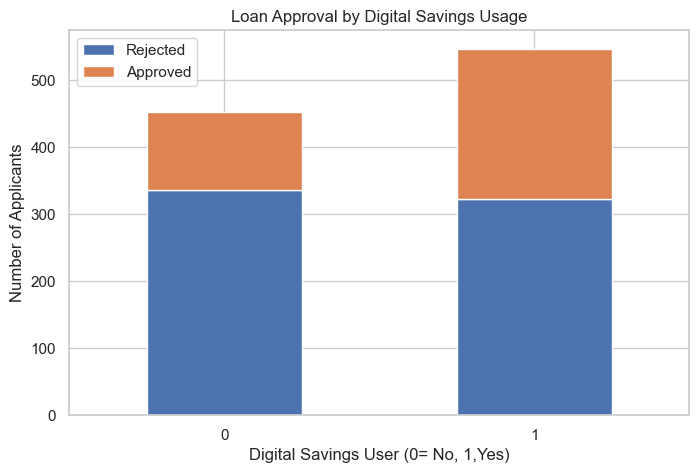

In [55]:
contingency_table.plot(kind = 'bar', stacked = True, figsize = (8,5))
plt.title('Loan Approval by Digital Savings Usage')
plt.xlabel('Digital Savings User (0= No, 1,Yes)')
plt.ylabel('Number of Applicants')
plt.legend(['Rejected','Approved'])
plt.xticks(rotation=0)
plt.show()

In [57]:
df.pivot_table(values = 'Monthly_Income_USD', index = 'Province', columns = 'Education', aggfunc = 'max')

Education,Bachelor,High School,Master,Unknown
Province,,,,
Battambang,1261.88,1409.00,949.00,885.95
Phnom Penh,1345.88,1409.00,1271.76,1178.15
Siem Reap,1358.56,1393.98,1409.00,1193.09


<Axes: xlabel='Digital_Savings_User', ylabel='count'>

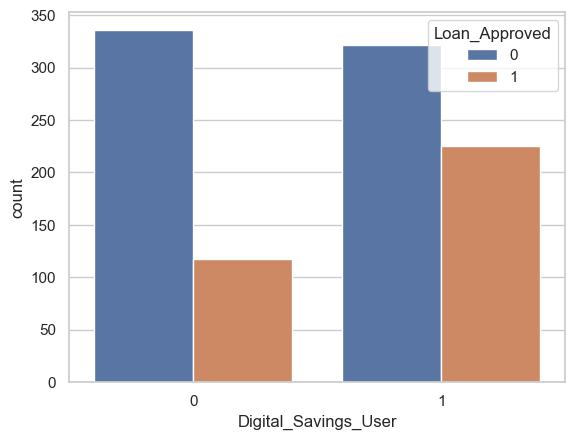

In [63]:
sns.countplot(x = 'Digital_Savings_User', hue = 'Loan_Approved',data = df)